# Метод 3 — Monte Carlo. Часть 3: holdout, Split CP, credible interval

In [1]:
from __future__ import annotations

import sys
from pathlib import Path
from dataclasses import dataclass

ROOT = Path('/Users/ensamsanovich/auc_forecast')
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

OUT_DIR = ROOT / 'outputs' / 'method_3_monte_carlo'
OUT_DIR.mkdir(parents=True, exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

from catboost import CatBoostRegressor

from core.config import ALPHA, INNER_CALIB_FRAC, MC_N_SIMS, SEED, TARGETS, set_seed
from core.runner import load_unified_data
from core.leak_safe_features import build_leak_safe_aggregates
from core.metrics import smlar, smlar_per_target, monotonicity_violation, monotonicity_violation_per_pair
from core.conformal import MultiTargetSplitCP
from core.ci import ConformalEvaluation, aggregate_cp_coverage, seeded_train_calib_split
from core.reporting import make_result, save_method_results

set_seed()

In [2]:
data = load_unified_data()
val = data['val']
ans = data['ans']
user_index = data['user_index']
pub_index = data['pub_index']
split = data['split']

train_idx = split['train_idx']
holdout_idx = split['holdout_idx']
folds = split['folds']

X = build_leak_safe_aggregates(val, user_index, pub_index)
y = ans[list(TARGETS)].astype(float).values
print(f"train/holdout: {len(train_idx)}/{len(holdout_idx)}, folds: {len(folds)}")

train/holdout: 806/202, folds: 5


In [3]:
def _nb_sample(mu, alpha, size, rng):
    mu = np.asarray(mu, dtype=np.float64)
    alpha = np.asarray(alpha, dtype=np.float64)
    out = np.empty(size, dtype=np.int64)
    poisson_mask = alpha < 1e-6
    if poisson_mask.any():
        out = rng.poisson(np.broadcast_to(mu, size).copy(), size=size)
    if (~poisson_mask).any():
        n = 1.0 / np.where(poisson_mask, 1.0, alpha)
        p = n / (n + mu)
        n = np.broadcast_to(n, size).copy()
        p = np.broadcast_to(p, size).copy()
        out_nb = rng.negative_binomial(n, p, size=size)
        out = np.where(np.broadcast_to(poisson_mask, size), out, out_nb)
    return out

@dataclass
class MCResult:
    reach_samples: np.ndarray
    thresholds: tuple
    @property
    def mean(self):
        return self.reach_samples.mean(axis=0)
    def quantile(self, q):
        return np.quantile(self.reach_samples, q, axis=0)
    def credible_interval(self, alpha=0.10):
        return self.quantile(alpha / 2), self.quantile(1 - alpha / 2)

def simulate_reach(mu, alpha, n_simulations=500, thresholds=(1, 2, 3), seed=42):
    mu = np.asarray(mu, dtype=np.float64).ravel()
    if np.isscalar(alpha):
        alpha = np.full_like(mu, float(alpha))
    else:
        alpha = np.asarray(alpha, dtype=np.float64).ravel()
    n_users = mu.shape[0]
    if n_users == 0:
        return MCResult(np.zeros((n_simulations, len(thresholds))), thresholds)
    rng = np.random.default_rng(seed)
    samples = _nb_sample(mu, alpha, size=(n_simulations, n_users), rng=rng)
    reach = np.stack([(samples >= k).mean(axis=1) for k in thresholds], axis=1)
    return MCResult(reach_samples=reach, thresholds=tuple(thresholds))

def _per_user_rates(user_ids, cutoff_hour, user_index):
    rates = []
    for uid in user_ids:
        feats = user_index.user_features_before(int(uid), cutoff_hour)
        n_imps = feats[0]
        is_cold = feats[4]
        if is_cold == 1.0 or cutoff_hour == 0:
            rates.append(np.nan)
        else:
            rates.append(n_imps / max(cutoff_hour, 1))
    rates = np.array(rates, dtype=np.float64)
    known = rates[~np.isnan(rates)]
    fallback = float(np.mean(known)) if known.size else 0.0
    rates = np.where(np.isnan(rates), fallback, rates)
    return rates

def _build_naive_predictions(val_df, user_index, alpha_disp, n_sims):
    means = np.zeros((len(val_df), 3))
    lows = np.zeros((len(val_df), 3))
    highs = np.zeros((len(val_df), 3))
    for i in range(len(val_df)):
        row = val_df.iloc[i]
        cutoff = int(row['hour_start'])
        duration = int(row['hour_end'] - row['hour_start'])
        rates = _per_user_rates(row['user_ids'], cutoff, user_index)
        mu = np.clip(rates * max(duration, 1), 1e-6, 1e3)
        res = simulate_reach(mu, alpha=alpha_disp, n_simulations=n_sims, seed=SEED + i)
        lo, hi = res.credible_interval(alpha=ALPHA)
        means[i], lows[i], highs[i] = res.mean, lo, hi
    return means, lows, highs

def fit_beta_correction(naive_train, y_train, X_train):
    models = []
    eps = 1e-6
    for t in range(3):
        log_ratio = np.log((y_train[:, t] + eps) / (naive_train[:, t] + eps))
        m = CatBoostRegressor(iterations=400, depth=4, learning_rate=0.05,
                              random_seed=SEED, verbose=0, allow_writing_files=False)
        m.fit(X_train.values, log_ratio)
        models.append(m)
    return models

def apply_beta(models, naive, X):
    out = np.zeros_like(naive)
    for t, m in enumerate(models):
        out[:, t] = naive[:, t] * np.exp(m.predict(X.values))
    return np.clip(out, 0.0, 1.0)

In [4]:
ALPHA_DISP = 2.21
S = MC_N_SIMS

naive_path = OUT_DIR / 'naive_preds.npy'
if naive_path.exists():
    naive = np.load(OUT_DIR / 'naive_preds.npy')
    naive_lo = np.load(OUT_DIR / 'naive_lo.npy')
    naive_hi = np.load(OUT_DIR / 'naive_hi.npy')
    print(f"Загружены наивные предсказания из части 2: {naive.shape}")
else:
    print(f"Считаем наивный MC для {len(val)} кампаний при S={S}...")
    naive, naive_lo, naive_hi = _build_naive_predictions(val, user_index, ALPHA_DISP, S)
    naive = np.clip(naive, 0.0, 1.0)
    np.save(OUT_DIR / 'naive_preds.npy', naive)
    np.save(OUT_DIR / 'naive_lo.npy', naive_lo)
    np.save(OUT_DIR / 'naive_hi.npy', naive_hi)
    print(f"naive.shape = {naive.shape}")

Загружены наивные предсказания из части 2: (1008, 3)


### CV-метрики и Split-CP по фолдам

In [5]:
fold_smlar_naive = []
fold_smlar_corr = []
fold_smlar_naive_pt = []  # per-target SMLAR для naive (без коррекции) — для диагностики
fold_smlar_corr_pt = []   # per-target SMLAR для corrected (то, что репортится)
fold_mono = []
fold_mono_pair = []
credible_cov_y1, credible_cov_y2, credible_cov_y3 = [], [], []
cp_evals = []

for fold_i, (tr, va) in enumerate(folds):
    fold_smlar_naive.append(smlar(y[va], naive[va]))
    fold_smlar_naive_pt.append(smlar_per_target(y[va], naive[va]))

    n_tr = len(tr)
    sub_local, cal_local = seeded_train_calib_split(n_tr, INNER_CALIB_FRAC, SEED + fold_i)
    sub_idx = tr[sub_local]
    cal_idx = tr[cal_local]

    models = fit_beta_correction(naive[sub_idx], y[sub_idx], X.iloc[sub_idx])
    pred_cal = apply_beta(models, naive[cal_idx], X.iloc[cal_idx])
    pred_va = apply_beta(models, naive[va], X.iloc[va])

    # post-hoc sort для монотонности
    pred_va_sorted = -np.sort(-pred_va, axis=1)
    pred_cal_sorted = -np.sort(-pred_cal, axis=1)
    fold_smlar_corr.append(smlar(y[va], pred_va_sorted))
    fold_smlar_corr_pt.append(smlar_per_target(y[va], pred_va_sorted))
    fold_mono.append(monotonicity_violation(pred_va_sorted))
    # mono_per_pair для corrected считаем ДО post-hoc сортировки —
    # после np.sort оно всегда нулевое, что скрывает реальную ошибку модели.
    fold_mono_pair.append(monotonicity_violation_per_pair(pred_va))

    cp = MultiTargetSplitCP(alpha=ALPHA).calibrate(y[cal_idx], pred_cal_sorted)
    lo, hi = cp.predict(pred_va_sorted)
    cp_evals.append(ConformalEvaluation(
        y_true=y[va].astype(np.float64),
        y_pred=pred_va_sorted.astype(np.float64),
        lower=lo, upper=hi,
        quantiles_per_target=[float(c.quantile_) for c in cp.per_target_],
    ))

    credible_cov_y1.append(((y[va, 0] >= naive_lo[va, 0]) & (y[va, 0] <= naive_hi[va, 0])).mean())
    credible_cov_y2.append(((y[va, 1] >= naive_lo[va, 1]) & (y[va, 1] <= naive_hi[va, 1])).mean())
    credible_cov_y3.append(((y[va, 2] >= naive_lo[va, 2]) & (y[va, 2] <= naive_hi[va, 2])).mean())
    print(f"  fold {fold_i + 1}: naive={fold_smlar_naive[-1]:.2f}%, corr={fold_smlar_corr[-1]:.2f}%, mono={fold_mono[-1]:.4f}")

cv_smlar_corr_pt_mean = {t: float(np.mean([d[t] for d in fold_smlar_corr_pt])) for t in TARGETS}
cv_smlar_corr_pt_std = {t: float(np.std([d[t] for d in fold_smlar_corr_pt], ddof=0)) for t in TARGETS}
cv_smlar_naive_pt_mean = {t: float(np.mean([d[t] for d in fold_smlar_naive_pt])) for t in TARGETS}
cv_mono_pair_mean_presort = {
    k: float(np.mean([d[k] for d in fold_mono_pair]))
    for k in ('y1_vs_y2', 'y2_vs_y3')
}
print()
print('per-target CV SMLAR (corrected):', {k: f'{v:.2f}%' for k, v in cv_smlar_corr_pt_mean.items()})
print('per-target CV SMLAR (naive):    ', {k: f'{v:.2f}%' for k, v in cv_smlar_naive_pt_mean.items()})
print('per-pair CV mono viol (до post-hoc sort):', {k: f'{v:.4f}' for k, v in cv_mono_pair_mean_presort.items()})

  fold 1: naive=409.72%, corr=29.87%, mono=0.0000
  fold 2: naive=392.96%, corr=27.22%, mono=0.0000
  fold 3: naive=447.91%, corr=29.23%, mono=0.0000
  fold 4: naive=310.55%, corr=29.19%, mono=0.0000
  fold 5: naive=420.07%, corr=25.67%, mono=0.0000

per-target CV SMLAR (corrected): {'at_least_one': '29.67%', 'at_least_two': '28.86%', 'at_least_three': '26.26%'}
per-target CV SMLAR (naive):     {'at_least_one': '320.82%', 'at_least_two': '453.58%', 'at_least_three': '425.05%'}
per-pair CV mono viol (до post-hoc sort): {'y1_vs_y2': '0.0533', 'y2_vs_y3': '0.1303'}


### Holdout: переобучение на полном train, предсказание, post-hoc sort

In [6]:
full_models = fit_beta_correction(naive[train_idx], y[train_idx], X.iloc[train_idx])
pred_ho = apply_beta(full_models, naive[holdout_idx], X.iloc[holdout_idx])
pred_ho_sorted = -np.sort(-pred_ho, axis=1)
ho_smlar = float(smlar(y[holdout_idx], pred_ho_sorted))
ho_mono = float(monotonicity_violation(pred_ho_sorted))
ho_smlar_pt = smlar_per_target(y[holdout_idx], pred_ho_sorted)
# mono_per_pair на holdout: до post-hoc сортировки (после неё всегда 0).
ho_mono_pair_presort = monotonicity_violation_per_pair(pred_ho)
print(f"Holdout SMLAR: {ho_smlar:.2f}%, monotonicity violation: {ho_mono:.4f}")
print(f"  per-target: { {k: f'{v:.2f}%' for k, v in ho_smlar_pt.items()} }")
print(f"  per-pair mono (до post-hoc sort): {ho_mono_pair_presort}")

sub_local_ho, cal_local_ho = seeded_train_calib_split(len(train_idx), INNER_CALIB_FRAC, SEED)
sub_idx_ho = train_idx[sub_local_ho]
cal_idx_ho = train_idx[cal_local_ho]
models_ho = fit_beta_correction(naive[sub_idx_ho], y[sub_idx_ho], X.iloc[sub_idx_ho])
pred_cal_ho = apply_beta(models_ho, naive[cal_idx_ho], X.iloc[cal_idx_ho])
pred_cal_ho_sorted = -np.sort(-pred_cal_ho, axis=1)
pred_ho2 = apply_beta(models_ho, naive[holdout_idx], X.iloc[holdout_idx])
pred_ho2_sorted = -np.sort(-pred_ho2, axis=1)

cp_ho = MultiTargetSplitCP(alpha=ALPHA).calibrate(y[cal_idx_ho], pred_cal_ho_sorted)
lo_ho, hi_ho = cp_ho.predict(pred_ho2_sorted)
print(f"CP holdout: shape = {lo_ho.shape}")

Holdout SMLAR: 23.85%, monotonicity violation: 0.0000
  per-target: {'at_least_one': '36.47%', 'at_least_two': '22.01%', 'at_least_three': '14.10%'}
  per-pair mono (до post-hoc sort): {'y1_vs_y2': 0.0049504950495049506, 'y2_vs_y3': 0.13861386138613863}
CP holdout: shape = (202, 3)


### Визуализация

In [7]:
rng_view = np.random.default_rng(SEED)
n_show = min(30, len(holdout_idx))
show_local = rng_view.choice(len(holdout_idx), size=n_show, replace=False)
show_local = np.sort(show_local)

TARGET_LABELS = ['reach@1', 'reach@2', 'reach@3']
xs = np.arange(3)

for k, local_i in enumerate(show_local, start=1):
    global_i = holdout_idx[local_i]
    yi = y[global_i]
    pi = pred_ho2_sorted[local_i]
    cp_lo = lo_ho[local_i]
    cp_hi = hi_ho[local_i]
    cr_lo = naive_lo[global_i]
    cr_hi = naive_hi[global_i]

    fig, ax = plt.subplots(figsize=(7.5, 5.0))
    ax.vlines(xs + 0.10, cr_lo, cr_hi, color='goldenrod', lw=4.0, alpha=0.45,
              linestyles='dashed', label='Credible (MC)')
    ax.vlines(xs - 0.10, cp_lo, cp_hi, color='steelblue', lw=4.0, alpha=0.95,
              label='Split CP')
    ax.scatter(xs - 0.10, pi, marker='o', color='navy', zorder=5, label='Прогноз')
    ax.scatter(xs, yi, marker='x', color='crimson', s=80, zorder=6, label='Истина')

    ax.set_xticks(xs)
    ax.set_xticklabels(TARGET_LABELS)
    y_top = float(max(cp_hi.max(), cr_hi.max(), yi.max(), pi.max(), 0.05)) * 1.15
    ax.set_ylim(0, y_top)
    ax.set_ylabel('Значение reach')
    ax.set_title(f"Holdout-кампания #{int(global_i)} ({k}/{n_show})")
    ax.grid(True, axis='y', ls=':', alpha=0.6)
    ax.legend(loc='upper right', fontsize=8)
    out_path = OUT_DIR / f"fig_cp_campaign_{k:03d}.png"
    plt.tight_layout()
    plt.savefig(out_path, dpi=110)
    plt.close()

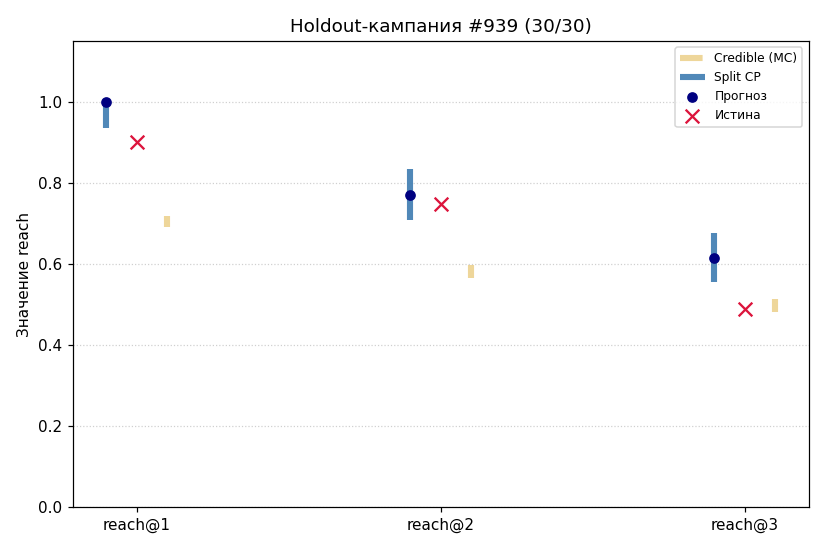

In [8]:
from IPython.display import Image, display

for k in range(n_show, n_show + 1):
    display(Image(OUT_DIR / f'fig_cp_campaign_{k:03d}.png'))

### Агрегация покрытия CP и credible

In [9]:
cp_agg = aggregate_cp_coverage(cp_evals)
credible_cov = {
    'at_least_one': float(np.mean(credible_cov_y1)),
    'at_least_two': float(np.mean(credible_cov_y2)),
    'at_least_three': float(np.mean(credible_cov_y3)),
}

result = make_result(
    method='monte_carlo+beta',
    split_protocol=split['protocol'],
    leak_safe=True,
    features='leak-safe 39-feat aggregates + per-user history rates',
    cv_smlar_flat_mean=float(np.mean(fold_smlar_corr)),
    cv_smlar_flat_std=float(np.std(fold_smlar_corr, ddof=0)),
    cv_smlar_per_target=cv_smlar_corr_pt_mean,
    cv_monotone_viol_mean=float(np.mean(fold_mono)),
    holdout_smlar=ho_smlar,
    holdout_monotone_viol=ho_mono,
    ci_type='split_cp',
    ci_alpha=ALPHA,
    ci_coverage_per_target=cp_agg['coverage_per_target'],
    ci_width_per_target=cp_agg['width_per_target'],
    source=f'notebook 03_holdout_cp_credible, S={S}, alpha_disp={ALPHA_DISP}',
    extra={
        'n_simulations': S,
        'alpha_dispersion': ALPHA_DISP,
        'naive_cv_smlar_mean': float(np.mean(fold_smlar_naive)),
        'naive_cv_smlar_std': float(np.std(fold_smlar_naive, ddof=0)),
        'naive_cv_smlar_per_target': cv_smlar_naive_pt_mean,
        'cv_smlar_per_target_std': cv_smlar_corr_pt_std,
        'cv_monotone_viol_per_pair_presort': cv_mono_pair_mean_presort,
        'holdout_smlar_per_target': ho_smlar_pt,
        'holdout_monotone_viol_per_pair_presort': ho_mono_pair_presort,
        'credible_coverage_per_target': credible_cov,
        'note_mono_pair': (
            'monotone_viol_per_pair считается ДО post-hoc сортировки np.sort(...)[::-1]. '
            'Финальные предсказания (что попадают в monotone_viol_mean=0) уже отсортированы; '
            'per-pair число — это диагностика «как часто β-CatBoost ошибается в порядке y_k».'
        ),
    },
)
save_method_results('monte_carlo', result)

PosixPath('/Users/ensamsanovich/auc_forecast/results/per_method/monte_carlo.json')

### Итоговая таблица

In [10]:
summary_rows = [
    ('CV SMLAR — naive MC', f"{np.mean(fold_smlar_naive):.2f}% ± {np.std(fold_smlar_naive):.2f}"),
    ('CV SMLAR — corrected', f"{np.mean(fold_smlar_corr):.2f}% ± {np.std(fold_smlar_corr):.2f}"),
    ('Holdout SMLAR — corrected', f"{ho_smlar:.2f}%"),
    ('Holdout monotonicity viol.', f"{ho_mono:.4f}"),
    ('CP coverage at_least_one', f"{cp_agg['coverage_per_target']['at_least_one']:.3f}"),
    ('CP coverage at_least_two', f"{cp_agg['coverage_per_target']['at_least_two']:.3f}"),
    ('CP coverage at_least_three', f"{cp_agg['coverage_per_target']['at_least_three']:.3f}"),
    ('Credible coverage at_least_one', f"{credible_cov['at_least_one']:.3f}"),
    ('Credible coverage at_least_two', f"{credible_cov['at_least_two']:.3f}"),
    ('Credible coverage at_least_three', f"{credible_cov['at_least_three']:.3f}"),
    ('CP width at_least_one', f"{cp_agg['width_per_target']['at_least_one']:.4f}"),
    ('CP width at_least_two', f"{cp_agg['width_per_target']['at_least_two']:.4f}"),
    ('CP width at_least_three', f"{cp_agg['width_per_target']['at_least_three']:.4f}"),
]
summary_df = pd.DataFrame(summary_rows, columns=['Метрика', 'Значение'])
print(summary_df.to_string(index=False))

                         Метрика        Значение
             CV SMLAR — naive MC 396.24% ± 46.42
            CV SMLAR — corrected   28.24% ± 1.56
       Holdout SMLAR — corrected          23.85%
      Holdout monotonicity viol.          0.0000
        CP coverage at_least_one           0.904
        CP coverage at_least_two           0.913
      CP coverage at_least_three           0.901
  Credible coverage at_least_one           0.021
  Credible coverage at_least_two           0.041
Credible coverage at_least_three           0.070
           CP width at_least_one          0.1085
           CP width at_least_two          0.0983
         CP width at_least_three          0.0704



- Применяем post-hoc сортировку `np.sort(...)[::-1]`, чтобы гарантировать монотонность
   reach@1 >= reach@2 >= reach@3.
- Считаем Split-CP интервалы (per-target) на holdout с калибровкой по внутренней подвыборке.
- В качестве альтернативного источника неопределённости сохраняем native credible-интервалы
   из MC-сэмплирования и сравниваем покрытие.